In [27]:
# Reproducible configuration
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import chi2, ncx2

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})
PROPOSED_COLOR = "#0072B2"

QQ_SEED = 123          # Q–Q null replications
POWER_SEED = 456       # Empirical power replications
POPULATION_SEED = 789  # Population-covariance reference curves
ALPHA = 0.05
PAPER_MODE = False  
SAVE_RESULTS = False  # If True, save tables/figures under Results/hypothesis_test.

if PAPER_MODE:
    NULL_DIMS = [2, 5, 10]
    NULL_N1 = [50, 250, 500]
    NULL_KAPPA = [5, 20]
    B_NULL = 5000
    B_POWER = 2000
    POPULATION_MC = 1_000_000
else:
    # Fast smoke-test grid; increase through PAPER_MODE only after checking the notebook.
    NULL_DIMS = [2, 5]
    NULL_N1 = [50, 250, 500]
    NULL_KAPPA = [5, 20]
    B_NULL = 5000  # Stable tail calibration for the Q–Q plot.
    B_POWER = 500
    POPULATION_MC = 100_000

POWER_D = 5
POWER_N1 = [50, 250, 500]
POWER_KAPPA = [5, 20]
SIGNED_H = [-4, -3, -2, -1, -0.5, 0, 0.5, 1, 2, 3, 4]

print({
    "qq_seed": QQ_SEED, "power_seed": POWER_SEED,
    "population_seed": POPULATION_SEED,
    "alpha": ALPHA, "paper_mode": PAPER_MODE,
    "B_null": B_NULL, "B_power": B_POWER,
    "population_MC_per_class": POPULATION_MC,
})


{'qq_seed': 123, 'power_seed': 456, 'population_seed': 789, 'alpha': 0.05, 'paper_mode': False, 'B_null': 5000, 'B_power': 500, 'population_MC_per_class': 100000}


In [28]:
SQRT3 = np.sqrt(3.0)
B0 = (5.0 - np.sqrt(21.0)) / 2.0


def g1(b):
    """Exact first-coordinate value of g_phi in the retained DGP family."""
    b = np.asarray(b)
    return 2.0 * (5.0 * b - (1.0 + b**2)) / (6.0 + b**2)


def theta_star(d, b=B0):
    out = np.zeros(d)
    out[0] = (1.0 + b) / (2.0 * (6.0 + b**2))
    return out


def true_g_phi(d, b=B0):
    out = np.zeros(d)
    out[0] = float(g1(b))
    return out


def sample_two_classes(rng, n0, n1, d, b=B0):
    U0 = rng.uniform(-SQRT3, SQRT3, size=(n0, d))
    U1 = rng.uniform(-SQRT3, SQRT3, size=(n1, d))
    e1 = np.zeros(d); e1[0] = 1.0
    D0 = np.ones(d); D0[0] = 2.0
    return -e1 + U0 * D0, b * e1 + U1

def scores(X, y, theta):
    return 2.0 * X * (X @ theta - y + 0.5)[:, None]


def sample_cov_rows(A):
    return np.cov(A, rowvar=False, ddof=1).reshape(A.shape[1], A.shape[1])


def symmetric_wald(vector, covariance, alpha=ALPHA, rtol=1e-10):
    covariance = 0.5 * (covariance + covariance.T)
    eigval, eigvec = np.linalg.eigh(covariance)
    scale = max(float(np.max(np.abs(eigval))), np.finfo(float).eps)
    singular = bool(eigval[0] <= rtol * scale)
    condition = np.inf if eigval[0] <= 0 else float(eigval[-1] / eigval[0])
    if singular:
        return np.nan, np.nan, False, True
    projection = eigvec.T @ vector
    statistic = float(np.sum(projection**2 / eigval))
    p_value = float(chi2.sf(statistic, len(vector)))
    return statistic, p_value, bool(p_value < alpha), False


def test_one_sample(X0, X1, alpha=ALPHA):
    n0, d = X0.shape; n1 = len(X1)
    S0 = X0.T @ X0 / n0
    S1 = X1.T @ X1 / n1
    theta_hat = 0.5 * np.linalg.solve(S0 + S1, X1.mean(0) - X0.mean(0))

    s0 = scores(X0, 0.0, theta_hat)
    s1 = scores(X1, 1.0, theta_hat)
    g_hat = s0.mean(0) - s1.mean(0)
    H0, H1 = 2.0 * S0, 2.0 * S1
    H = 0.5 * (H0 + H1)
    G = H0 - H1
    GHinv = np.linalg.solve(H.T, G.T).T
    A0 = np.eye(d) - 0.5 * GHinv
    A1 = -np.eye(d) - 0.5 * GHinv
    Sigma0, Sigma1 = sample_cov_rows(s0), sample_cov_rows(s1)

    V_corrected = A0 @ Sigma0 @ A0.T / n0 + A1 @ Sigma1 @ A1.T / n1
    T, p, reject, singular = symmetric_wald(g_hat, V_corrected, alpha)
    return {
        "method": "Corrected", "statistic": T, "p_value": p,
        "reject": reject, "singular": singular,
    }


print(f"Calibrated local-symmetry-null b0 = {B0:.10f}; g1(b0) = {g1(B0):.3e}")


Calibrated local-symmetry-null b0 = 0.2087121525; g1(b0) = 1.470e-16


In [29]:
def run_null_simulation(dims, n1_values, kappas, B, seed=QQ_SEED, alpha=ALPHA):
    rows = []
    settings = [(d, n1, k) for d in dims for n1 in n1_values for k in kappas]
    start = time.time()
    for setting_index, (d, n1, kappa) in enumerate(settings, 1):
        n0 = int(kappa * n1)
        setting_seed = int(np.random.SeedSequence([seed, d, n1, kappa]).generate_state(1)[0])
        rng = np.random.default_rng(setting_seed)
        for rep in range(B):
            X0, X1 = sample_two_classes(rng, n0, n1, d, B0)
            result = test_one_sample(X0, X1, alpha)
            rows.append({
                "d": d, "n0": n0, "n1": n1,
                "kappa": kappa, "rep": rep, "setting_seed": setting_seed,
                **result,
            })
        if setting_index == 1 or setting_index % max(1, len(settings)//10) == 0:
            print(f"null settings {setting_index}/{len(settings)}; elapsed {time.time()-start:.1f}s")
    return pd.DataFrame(rows)


null_raw = run_null_simulation(
    dims=NULL_DIMS,
    n1_values=NULL_N1, kappas=NULL_KAPPA, B=B_NULL, seed=QQ_SEED,
)
print(f"Completed {len(null_raw):,} corrected-Wald Monte Carlo samples.")


null settings 1/12; elapsed 7.5s
null settings 2/12; elapsed 17.0s
null settings 3/12; elapsed 26.4s
null settings 4/12; elapsed 38.0s
null settings 5/12; elapsed 41.6s
null settings 6/12; elapsed 48.2s
null settings 7/12; elapsed 50.2s
null settings 8/12; elapsed 52.9s
null settings 9/12; elapsed 56.2s
null settings 10/12; elapsed 61.8s
null settings 11/12; elapsed 66.0s
null settings 12/12; elapsed 75.6s
Completed 60,000 corrected-Wald Monte Carlo samples.


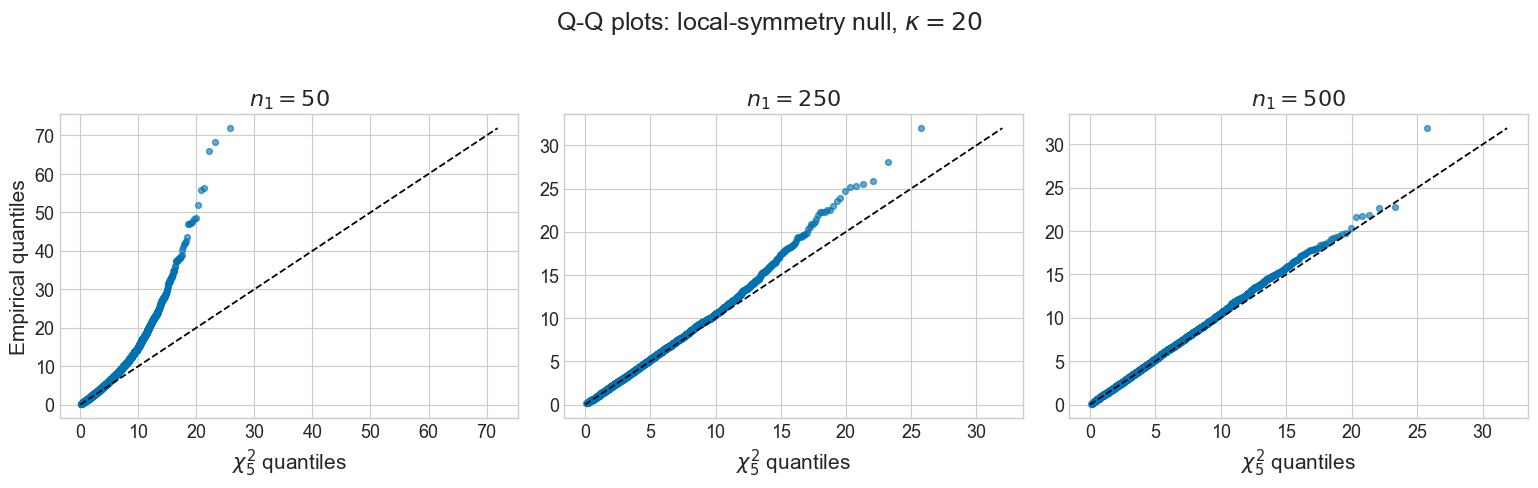

In [30]:
def plot_null_qq(raw, d=5, kappa=20):
    available_d = sorted(raw["d"].unique())
    if d not in available_d:
        d = available_d[-1]
    subset = raw.query("d == @d and kappa == @kappa")
    if subset.empty:
        kappa = sorted(raw.loc[raw.d == d, "kappa"].unique())[-1]
        subset = raw.query("d == @d and kappa == @kappa")
    chosen_n1 = sorted(subset.n1.unique())

    fig, axes = plt.subplots(1, len(chosen_n1), figsize=(5.2*len(chosen_n1), 4.8), squeeze=False)
    for ax, n1 in zip(axes[0], chosen_n1):
        values = np.sort(subset.loc[(subset.n1 == n1) & ~subset.singular, "statistic"].dropna().to_numpy())
        probs = (np.arange(len(values)) + 0.5) / len(values)
        theory = chi2.ppf(probs, d)
        ax.scatter(theory, values, s=18, alpha=0.60, color=PROPOSED_COLOR)
        limit = max(theory.max(), values.max())
        ax.plot([0, limit], [0, limit], "--", color="black", lw=1.3)
        ax.set(title=rf"$n_1={n1}$", xlabel=rf"$\chi^2_{{{d}}}$ quantiles")
    axes[0, 0].set_ylabel("Empirical quantiles")
    fig.suptitle(rf"Q-Q plots: local-symmetry null, $\kappa={kappa}$", y=1.02)
    fig.tight_layout()
    return fig


qq_figure = plot_null_qq(null_raw)
plt.show()


In [31]:
def b_for_target(target, grid=(-4.0, 8.0), points=20001):
    """Root closest to b0, on the direction implied by the signed target."""
    if abs(target) < 1e-14:
        return B0
    xs = np.linspace(grid[0], grid[1], points)
    vals = g1(xs) - target
    roots = []
    hit = np.where(vals[:-1] * vals[1:] <= 0)[0]
    for i in hit:
        try:
            roots.append(brentq(lambda z: float(g1(z) - target), xs[i], xs[i+1]))
        except ValueError:
            pass
    directional = [r for r in roots if (r-B0)*target >= 0]
    candidates = directional or roots
    if not candidates:
        raise ValueError(f"No b solves g1(b)={target:.4g} on search interval {grid}.")
    return min(candidates, key=lambda r: abs(r-B0))


def population_corrected_covariance(d, b, n0, n1, mc_size, seed):
    rng = np.random.default_rng(seed)
    X0, X1 = sample_two_classes(rng, mc_size, mc_size, d, b)
    theta = theta_star(d, b)
    s0, s1 = scores(X0, 0.0, theta), scores(X1, 1.0, theta)
    H0 = 2.0 * (X0.T @ X0 / mc_size)
    H1 = 2.0 * (X1.T @ X1 / mc_size)
    H, G = 0.5*(H0+H1), H0-H1
    GHinv = np.linalg.solve(H.T, G.T).T
    A0, A1 = np.eye(d)-0.5*GHinv, -np.eye(d)-0.5*GHinv
    return A0 @ sample_cov_rows(s0) @ A0.T / n0 + A1 @ sample_cov_rows(s1) @ A1.T / n1


def run_local_power(
    d, n1_values, kappas, signed_h, B, population_mc,
    seed=POWER_SEED, population_seed=POPULATION_SEED, alpha=ALPHA,
):
    raw_rows, summary_rows = [], []
    critical = chi2.ppf(1-alpha, d)
    settings = [(n1, k, h) for n1 in n1_values for k in kappas for h in signed_h]
    start = time.time()
    for index, (n1, kappa, h) in enumerate(settings, 1):
        n0 = int(kappa*n1)
        n_eff = n0*n1/(n0+n1)
        target = h/np.sqrt(n_eff)
        b = b_for_target(target)
        h_code = int(round(1000 * (h + 10)))
        setting_seed = int(
            np.random.SeedSequence([seed, d, n1, kappa, h_code]).generate_state(1)[0]
        )
        rng = np.random.default_rng(setting_seed)
        rejected = 0
        valid = 0
        for rep in range(B):
            X0, X1 = sample_two_classes(rng, n0, n1, d, b)
            result = test_one_sample(X0, X1, alpha)
            if not result["singular"]:
                valid += 1
                rejected += int(result["reject"])
            raw_rows.append({
                "d": d, "n0": n0, "n1": n1, "kappa": kappa, "h": h,
                "target_g1": target, "b": b, "rep": rep,
                "setting_seed": setting_seed, **result,
            })
        reference_seed = int(
            np.random.SeedSequence(
                [population_seed, d, n0, n1, h_code]
            ).generate_state(1)[0]
        )
        V_pop = population_corrected_covariance(
            d, b, n0, n1, population_mc, seed=reference_seed
        )
        g = true_g_phi(d, b)
        lambda_n = symmetric_wald(g, V_pop, alpha)[0]
        predicted = float(ncx2.sf(critical, d, lambda_n))
        summary_rows.append({
            "d": d, "n0": n0, "n1": n1, "kappa": kappa, "h": h,
            "target_g1": target, "abs_g": abs(target), "b": b, "method": "Corrected",
            "power": rejected/valid if valid else np.nan,
            "valid_B": valid, "lambda": lambda_n,
            "standardized_signal": np.sqrt(lambda_n), "predicted_power": predicted,
            "setting_seed": setting_seed, "reference_seed": reference_seed,
        })
        if index == 1 or index % max(1, len(settings)//10) == 0:
            print(f"power settings {index}/{len(settings)}; elapsed {time.time()-start:.1f}s")
    return pd.DataFrame(raw_rows), pd.DataFrame(summary_rows)


power_raw, power_summary = run_local_power(
    d=POWER_D, n1_values=POWER_N1, kappas=POWER_KAPPA,
    signed_h=SIGNED_H, B=B_POWER, population_mc=POPULATION_MC,
    seed=POWER_SEED, population_seed=POPULATION_SEED,
)


power settings 1/66; elapsed 0.3s
power settings 6/66; elapsed 1.5s
power settings 12/66; elapsed 3.2s
power settings 18/66; elapsed 5.1s
power settings 24/66; elapsed 7.2s
power settings 30/66; elapsed 9.5s
power settings 36/66; elapsed 12.4s
power settings 42/66; elapsed 17.2s
power settings 48/66; elapsed 22.2s
power settings 54/66; elapsed 25.8s
power settings 60/66; elapsed 32.9s
power settings 66/66; elapsed 39.3s


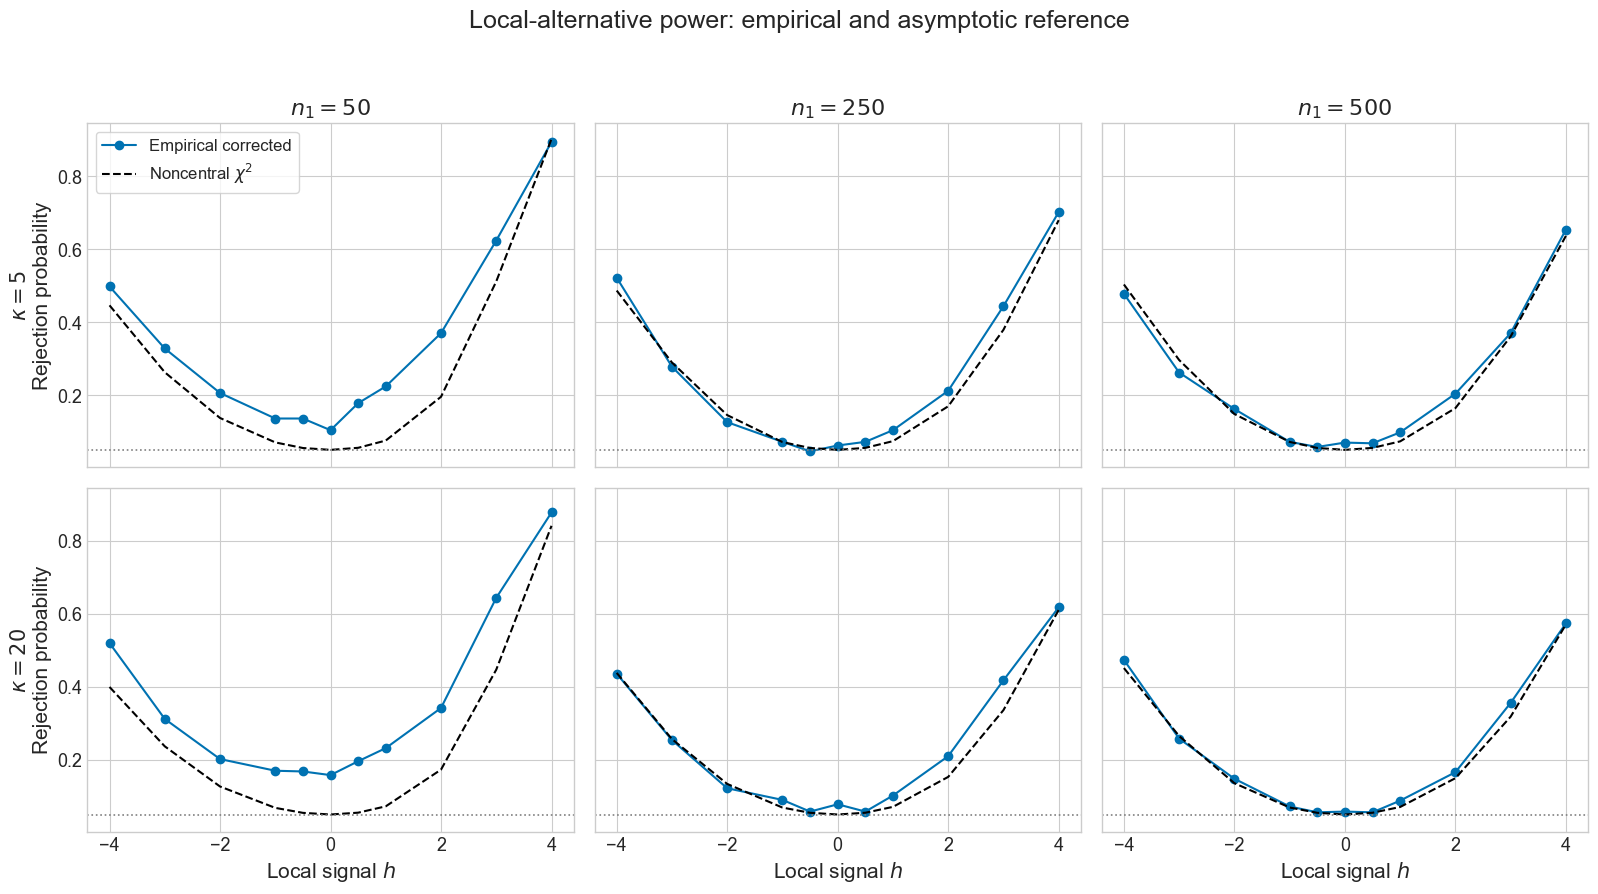

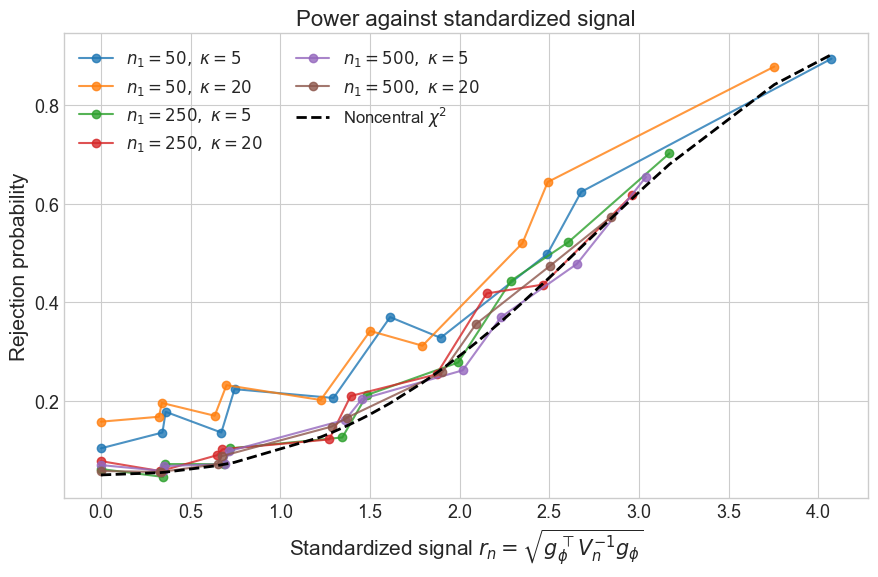

In [32]:
def plot_power(summary):
    corrected = summary.query("method == 'Corrected'").copy()
    n1_values = sorted(corrected["n1"].astype(int).unique())
    kappa_values = sorted(corrected["kappa"].astype(int).unique())
    fig, axes = plt.subplots(
        len(kappa_values), len(n1_values),
        figsize=(5.4*len(n1_values), 4.5*len(kappa_values)),
        squeeze=False, sharex=True, sharey=True,
    )
    for row, kappa in enumerate(kappa_values):
        for col, n1 in enumerate(n1_values):
            ax = axes[row, col]
            part = corrected.query("n1 == @n1 and kappa == @kappa").sort_values("h")
            ax.plot(part.h, part.power, "o-", color=PROPOSED_COLOR, label="Empirical corrected")
            ax.plot(part.h, part.predicted_power, "--", color="black", label=r"Noncentral $\chi^2$")
            ax.axhline(ALPHA, color="gray", ls=":", lw=1.2)
            if row == 0:
                ax.set_title(rf"$n_1={n1}$")
            if col == 0:
                ax.set_ylabel(rf"$\kappa={kappa}$" + "\nRejection probability")
            if row == len(kappa_values)-1:
                ax.set_xlabel(r"Local signal $h$")
    axes[0, 0].legend(frameon=True, loc="best")
    fig.suptitle("Local-alternative power: empirical and asymptotic reference", y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    fig2, ax2 = plt.subplots(figsize=(9, 6))
    for (n1, kappa), part in corrected.groupby(["n1", "kappa"]):
        part = part.sort_values("standardized_signal")
        ax2.plot(part.standardized_signal, part.power, "o-", alpha=0.8,
                 label=rf"$n_1={n1},\ \kappa={kappa}$")
    reference = corrected.sort_values("standardized_signal")
    ax2.plot(reference.standardized_signal, reference.predicted_power,
             "k--", lw=2, label=r"Noncentral $\chi^2$")
    ax2.set(xlabel=r"Standardized signal $r_n=\sqrt{g_\phi^\top V_n^{-1}g_\phi}$",
            ylabel="Rejection probability", title="Power against standardized signal")
    ax2.legend(ncol=2)
    fig2.tight_layout()
    return fig, fig2


power_figure, standardized_power_figure = plot_power(power_summary)
plt.show()
